In [116]:
import yaml
import pypsa
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [117]:
with open(Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

In [2]:
template = 'base_s_50__168H-T-H-B-I-A-dist1{}_2030_free{}_endo.nc'

In [3]:
sector_opts = [
    '',
    '-gas+Generator+m1.1',
    '-gas+Generator+m1.2',
    '-gas+Generator+m1.3',
    '-gas+Generator+m1.4',
    '-gas+Generator+m1.5',
    '-gas+Generator+m1.6',
    '-gas+Generator+m1.7',
    '-gas+Generator+m1.8',
    '-gas+Generator+m1.9',
    '-gas+Generator+m2.0',
]

In [4]:
tyndp_scenarios = [
    '',
    '+carbonprice-50',
    '+carbonprice-60',
    '+carbonprice-70',
    '+carbonprice-80',
    '+carbonprice-90',
    '+carbonprice-100',
    '+carbonprice-110',
    '+carbonprice-120',
]

In [5]:
idx = pd.IndexSlice

In [6]:
def get_gas_consumption(n):
    return n.statistics.energy_balance().loc[idx[:,'gas',:]].iloc[0] / 1e6

In [182]:
def get_expense_stack(n):
    """
    Retrieve a dictionary mapping carrier to network (n) "load stack" costs,
    summing price * p_set * snapshot_weighting over all loads by carrier.
    Output is in the units of the underlying calculation (usually €).
    """
    w = n.snapshot_weightings['generators']
    expense_tracker = {}

    for i, col in enumerate(n.buses_t.marginal_price.columns):

        prices = n.buses_t.marginal_price[col]

        if len((s := n.loads.loc[n.loads['bus'] == col])) > 0:

            for load_name, ss in s.iterrows():

                carrier = ss.loc['carrier']

                if load_name in n.loads_t.p_set.columns:
                    p_set = n.loads_t.p_set.loc[:, load_name]
                else:
                    p_set = n.loads.loc[load_name, 'p_set']
                
                expenses = (prices.mul(p_set).mul(w)).sum()

                if carrier not in expense_tracker:
                    expense_tracker[carrier] = expenses
                else:
                    expense_tracker[carrier] += expenses

            # (no need for `else: continue` block here)

    return pd.Series(expense_tracker)

In [186]:
from itertools import product

data = pd.DataFrame(index=sector_opts, columns=tyndp_scenarios)
consumer_spending = pd.DataFrame(index=sector_opts, columns=tyndp_scenarios)

for sector_opt, tyndp_scenario in product(sector_opts, tyndp_scenarios):

    n = pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' / template.format(sector_opt, tyndp_scenario)
    )
    data.loc[sector_opt, tyndp_scenario] = get_gas_consumption(n)
    expense_stack = get_expense_stack(n)
    consumer_spending.loc[sector_opt, tyndp_scenario] = expense_stack.sum()

data.loc[sector_opts, tyndp_scenarios]

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free+carbonprice-50_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free+carbonprice-60_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free+carbonprice-70_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free+carbonprice-80_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-

,,+carbonprice-50,+carbonprice-60,+carbonprice-70,+carbonprice-80,+carbonprice-90,+carbonprice-100,+carbonprice-110,+carbonprice-120
,3318.624602,1951.545538,1747.029003,1615.732653,1364.798365,1296.365353,1219.463005,1157.297162,932.534284
-gas+Generator+m1.1,2890.856541,1710.081278,1566.109421,1338.781199,1272.748442,1198.194594,1122.147318,907.361396,846.544303
-gas+Generator+m1.2,2589.799142,1516.565437,1321.509828,1248.948937,1176.445817,949.504935,883.813803,830.831788,777.025348
-gas+Generator+m1.3,2294.178989,1306.135916,1224.141015,1156.01366,932.104632,868.289883,813.021471,763.68098,717.88434
-gas+Generator+m1.4,1959.827712,1207.185942,1144.780488,916.089843,850.56918,802.788554,754.203268,693.274914,618.604745
-gas+Generator+m1.5,1713.359148,1121.563171,900.656454,838.348107,793.695672,737.370072,668.579453,595.691762,503.28866
-gas+Generator+m1.6,1526.019721,880.962627,829.921257,781.728556,724.643442,650.663481,570.474098,472.821713,390.724307
-gas+Generator+m1.7,1307.274148,810.134627,770.771893,701.077328,622.851141,529.03924,432.35142,363.26814,326.043901
-gas+Generator+m1.8,1208.116067,762.905343,688.839843,599.107778,501.379728,413.674439,350.136856,317.265999,291.507413
-gas+Generator+m1.9,1123.672375,672.159084,584.950834,481.294694,395.159728,338.5089,312.073994,284.162841,260.181541


In [187]:
base_n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_free_endo.nc'
)
base_gas_cost = base_n.generators.loc[base_n.generators.carrier == 'gas', 'marginal_cost'].iloc[0]

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [188]:
def household_cost_burden(
    carbon_price_eur_per_tco2,
    gas_tax_eur_per_mwh,
    gas_consumption_mwh=15,
    oil_consumption_mwh=10,
    ef_gas=0.2,
    ef_oil=0.27
    ):
    """
    Annual household cost burden from a carbon tax and/or gas tax.

    Parameters
    ----------
    carbon_price_eur_per_tco2 : float – carbon tax in €/tCO₂
    gas_tax_eur_per_mwh       : float – gas-specific tax in €/MWh
    gas_consumption_mwh       : float – household gas use (default 15 MWh/yr)
    oil_consumption_mwh       : float – household oil/petrol use (default 10 MWh/yr)
    ef_gas                    : float – emission factor gas (default 0.2 tCO₂/MWh)
    ef_oil                    : float – emission factor oil (default 0.27 tCO₂/MWh)

    Returns
    -------
    dict with carbon_tax_cost, gas_tax_cost, and total_cost (all €/yr)
    """
    carbon_tax_cost = carbon_price_eur_per_tco2 * (
        gas_consumption_mwh * ef_gas + oil_consumption_mwh * ef_oil
    )
    gas_tax_cost = gas_tax_eur_per_mwh * gas_consumption_mwh
    return {
        "carbon_tax_cost": round(carbon_tax_cost, 2),
        "gas_tax_cost": round(gas_tax_cost, 2),
        "total_cost": round(carbon_tax_cost + gas_tax_cost, 2),
    }

In [189]:
consumption = data.copy()

def get_carbonprice(x):
    if x == '':
        return 0
    else:
        return int(x.split('-')[1])

def get_gas_tax(x):
    if x == '':
        return 0
    else:
        return float(x.split('+m')[1]) * base_gas_cost - base_gas_cost



consumption.columns = list(map(get_carbonprice, consumption.columns))
consumption.index = list(map(get_gas_tax, consumption.index))

consumer_spending.columns = list(map(get_carbonprice, consumer_spending.columns))
consumer_spending.index = list(map(get_gas_tax, consumer_spending.index))

In [190]:
consumption.head()

,0,50,60,70,80,90,100,110,120
0.000000,3318.624602,1951.545538,1747.029003,1615.732653,1364.798365,1296.365353,1219.463005,1157.297162,932.534284
2.457832,2890.856541,1710.081278,1566.109421,1338.781199,1272.748442,1198.194594,1122.147318,907.361396,846.544303
4.915665,2589.799142,1516.565437,1321.509828,1248.948937,1176.445817,949.504935,883.813803,830.831788,777.025348
7.373497,2294.178989,1306.135916,1224.141015,1156.01366,932.104632,868.289883,813.021471,763.68098,717.88434
9.831330,1959.827712,1207.185942,1144.780488,916.089843,850.56918,802.788554,754.203268,693.274914,618.604745


In [191]:
consumer_spending.head()

,0,50,60,70,80,90,100,110,120
0.000000,638938424510.195557,737129750052.393066,754777562071.422729,771802729697.783325,789675813954.08728,807662911231.785156,825879058863.577026,843057013013.177124,859889996077.979614
2.457832,650772137981.91748,744617451328.789551,761711519539.229736,778956843099.922363,797185895288.127441,814657497617.101685,832009825183.489136,848916513538.18689,865516759815.056641
4.915665,661356940085.582886,751603645481.924561,768888945698.102173,786561218352.40564,803613714360.091553,820579867974.806519,837721876514.451172,854477880445.098633,870474171946.35022
7.373497,670786303226.180298,758891821417.641724,776609833180.715942,793095938137.241577,809591618564.608276,826517532680.562378,843274219785.096436,859168996676.677734,875175564908.329468
9.831330,679702166108.353882,766573024257.741577,782896903982.295898,799515191170.140625,815722563184.073242,831915855922.012207,847694137887.273193,863964783450.300415,879346834114.153198


In [196]:
# burden = pd.DataFrame(index=consumption.index, columns=consumption.columns)

# for i in range(len(consumption.index)):
    # for j in range(len(consumption.columns)):
    #     burden.iloc[i, j] = household_cost_burden(consumption.index[i], consumption.columns[j])['total_cost']
burden = (consumer_spending - consumer_spending.iloc[0, 0]) / 743_000_000

burden

,0,50,60,70,80,90,100,110,120
0.000000,0.0,132.155216,155.907318,178.821407,202.876702,227.085446,251.602469,274.722192,297.37762
2.457832,15.926936,142.232876,165.239697,188.450092,212.984483,236.499425,259.853837,282.608464,304.950653
4.915665,30.172968,151.63556,174.899759,198.684783,221.635653,244.470314,267.541658,290.09348,311.622809
7.373497,42.863901,161.44468,185.291263,207.47983,229.681284,252.461788,275.014529,296.40723,317.950391
9.831330,54.863717,171.782772,193.753001,216.119471,237.932892,259.727364,280.963275,302.861856,323.564481
12.289162,65.039533,180.089143,202.331545,224.192086,244.605641,265.663374,287.518417,308.18548,327.444509
14.746994,74.375477,188.668035,210.283122,230.913629,251.38582,272.262147,292.694202,312.209129,332.188448
17.204827,84.199215,196.126938,216.712071,237.199252,258.034063,277.447986,296.958369,316.732061,336.463895
19.662659,94.65036,202.859593,223.440609,243.515417,262.590405,281.786998,301.297759,321.027647,339.900728
22.120491,102.807137,209.580889,229.409542,248.143874,267.167279,286.086926,305.440407,324.481355,343.404396


In [198]:
ng = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / template.format('-gas+Generator+m1.4', '')
)
nbase = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / template.format('', '')
)
nc = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / template.format('', '+carbonprice-50')
)

w = ng.snapshot_weightings['generators']

expense_tracker_ng = {}
expense_tracker_nc = {}

for i, col in enumerate(ng.buses_t.marginal_price.columns):

    prices_ng = ng.buses_t.marginal_price[col]
    prices_nc = nc.buses_t.marginal_price[col]

    if len((s := ng.loads.loc[ng.loads['bus'] == col])) > 0:

        for load_name, ss in s.iterrows():

            carrier = ss.loc['carrier']

            if load_name in ng.loads_t.p_set.columns:
                p_set_ng = ng.loads_t.p_set.loc[:, load_name]
                p_set_nc = nc.loads_t.p_set.loc[:, load_name]
            else:
                p_set_ng = ng.loads.loc[load_name, 'p_set']
                p_set_nc = nc.loads.loc[load_name, 'p_set']
            
            expenses_ng = (prices_ng.mul(p_set_ng).mul(w)).sum()
            expenses_nc = (prices_nc.mul(p_set_nc).mul(w)).sum()

            if carrier not in expense_tracker_ng:
                expense_tracker_ng[carrier] = expenses_ng
                expense_tracker_nc[carrier] = expenses_nc
            else:
                expense_tracker_ng[carrier] += expenses_ng
                expense_tracker_nc[carrier] += expenses_nc

        else:
            continue

expense_diff = pd.concat((
    pd.Series(expense_tracker_ng, name='ng'),
    pd.Series(expense_tracker_nc, name='nc')
), axis=1) / 1e9
expense_diff['diff'] = expense_diff['nc'] - expense_diff['ng']
# expense_diff.round().astype(int)


INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1-gas+Generator+m1.4_2030_free_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free+carbonprice-50_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


0 0.34811151777076654 0.6962230355415331
0.6962230355415331 5.732095573169155 10.071745075255244
10.767968110796776 27.868432014085744 34.20092780657794
44.96889591737471 45.26078889518621 0.5837859556230072
45.55268187299772 48.880950575819895 6.656537405644357
52.209219278642074 53.21260298912697 2.0067674209697977
54.215986699611875 55.62087887117568 2.809784343127596


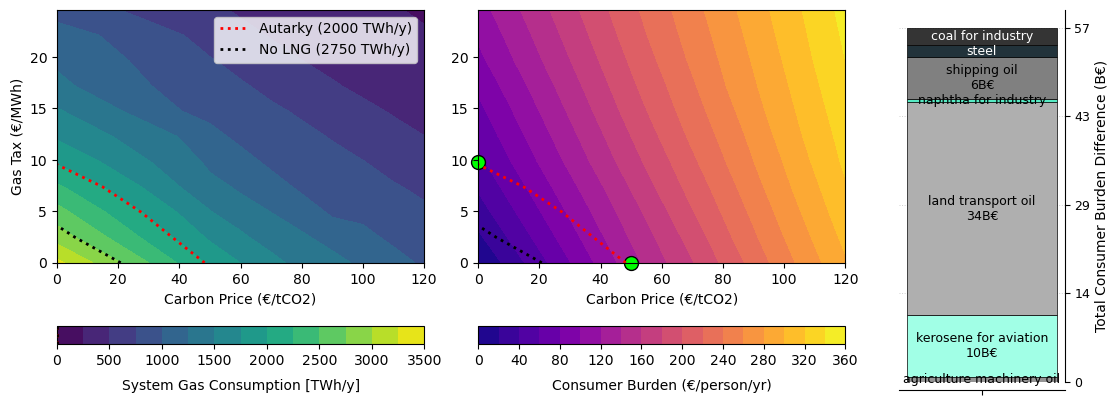

In [201]:
from matplotlib import gridspec

# Create a figure with custom GridSpec for variable width axes
fig = plt.figure(figsize=(13, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.45], wspace=0.18)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])

# --- First axis: gas consumption contour plot ---
# Ensure values are float and no dtype issues
consumption_np = consumption.values.astype(float)
burden_np = burden.values.astype(float)
# Meshgrid for axes
X, Y = np.meshgrid(consumption.columns.values.astype(float), consumption.index.values.astype(float))
# Define level range with step size 250, covering min/max including special contour levels
vmin = np.floor(np.nanmin(consumption_np) / 250) * 250
vmax = np.ceil(np.nanmax(consumption_np) / 250) * 250
levels = np.arange(vmin, vmax + 1, 250)

cf1 = ax0.contourf(X, Y, consumption_np, levels=levels, cmap="viridis")
cb1 = plt.colorbar(cf1, ax=ax0, orientation="horizontal", pad=0.17)
cb1.set_label("System Gas Consumption [TWh/y]", fontsize=10, labelpad=8)
ax0.set_xlabel("Carbon Price (€/tCO2)")
ax0.set_ylabel("Gas Tax (€/MWh)")
# Draw contour lines for z = 2000 and z = 2500
contour_colors = ['red', 'k']
contour_labels = ['Autarky (2000 TWh/y)', 'No LNG (2750 TWh/y)']
contour_levels = [2000, 2750]

# Add the two contour lines as vertical lines on the colorbar
cbar_ax = cb1.ax
norm = cf1.norm
vmin, vmax = cf1.get_clim()
for color, level in zip(contour_colors, contour_levels):
    if hasattr(norm, 'vmin') and hasattr(norm, 'vmax'):
        vmin, vmax = norm.vmin, norm.vmax
    # Normalize the contour level to the colorbar axis [0, 1]
    normed = (level - vmin) / (vmax - vmin)
    cbar_ax.axvline(normed, color=color, linestyle='dotted', lw=2, zorder=10)
lines = ax0.contour(
    X, Y, consumption_np, 
    levels=contour_levels, 
    colors=contour_colors, 
    linestyles='dotted',
    linewidths=2
)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=contour_colors[0], linestyle='dotted', lw=2, label=contour_labels[0]),
    Line2D([0], [0], color=contour_colors[1], linestyle='dotted', lw=2, label=contour_labels[1])
]
ax0.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, title=None)
# --- Draw dotted lines on the colorbar for special contours ---
from matplotlib.colors import Normalize
cbar_ax = cb1.ax
norm = cf1.norm
vmin, vmax = cf1.get_clim()
for color, level in zip(contour_colors, contour_levels):
    if hasattr(norm, 'vmin') and hasattr(norm, 'vmax'):
        vmin, vmax = norm.vmin, norm.vmax
    normed = (level - vmin) / (vmax - vmin)
    cbar_ax.axvline(normed, color=color, linestyle='dotted', lw=2, zorder=10)

# --- Second axis: household burden contour plot ---
cf2 = ax1.contourf(X, Y, burden_np, levels=20, cmap="plasma")
cb2 = plt.colorbar(cf2, ax=ax1, orientation="horizontal", pad=0.17)
cb2.set_label("Consumer Burden (€/person/yr)", fontsize=10, labelpad=8)
ax1.set_xlabel("Carbon Price (€/tCO2)")
# ax1.set_ylabel("Gas Tax (€/MWh)")
for color, level in zip(contour_colors, contour_levels):
    ax1.contour(
        X, Y, consumption_np,
        levels=[level],
        colors=[color],
        linestyles='dotted',
        linewidths=2
    )

gastax_only = pd.Series(
    Y[:,0],
    index=consumption_np[:,0]
)

# Interpolate to find the value where the index (i.e., consumption) would be 2000
gastax_only.loc[2000] = np.nan
gastax_at_2000 = gastax_only.sort_index().interpolate().sort_index().loc[2000]
gastax_at_2000 = 9.8

carbontax_only = pd.Series(
    X[0],
    index=consumption_np[0]
)

# Interpolate to find the value where the index (i.e., consumption) would be 2000
carbontax_only.loc[2000] = np.nan
carbontax_at_2000 = carbontax_only.sort_index().interpolate().sort_index().loc[2000]
carbontax_at_2000 = 50

ax1.scatter(
    [carbontax_at_2000, 0],
    [0, gastax_at_2000],
    s=100,
    edgecolor='k',
    c='lime',
    clip_on=False  # ensure points are visible even if outside axes
)

# --- Third axis: barplot of expense_diff['diff'] ---
# Plot only nonzero entries
diff_nonzero = expense_diff['diff'][expense_diff['diff'] > 0.5]

# Ensure index is str for labeling
diff_nonzero = diff_nonzero.copy()
diff_nonzero.index = diff_nonzero.index.astype(str)

# Prepare data for a vertical stacked barplot (single stacked bar)
bar_colors = [tech_colors.get(k, "#444444") for k in diff_nonzero.index]
bar_labels = [str(k) for k in diff_nonzero.index]
bar_values = diff_nonzero.values

# To stack: offset for each stack
bottoms = np.cumsum(np.insert(bar_values, 0, 0))[:-1]

# Plot a single vertical bar at x=0, stacked, and annotate each segment immediately
import matplotlib.colors as mcolors

def is_dark(color):
    # Convert color name/hex to RGB, then to perceived luminance
    rgb = mcolors.to_rgb(color)
    luminance = 0.2126*rgb[0] + 0.7152*rgb[1] + 0.0722*rgb[2]
    return luminance < 0.45

max_val = np.sum(bar_values)
yticks = np.linspace(0, max_val, 5)
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.set_yticks(yticks)
ax2.set_yticklabels([f"{y:.0f}" for y in yticks], fontsize=9)
ax2.set_ylabel("Total Consumer Burden Difference (B€)", fontsize=10, labelpad=20)  # add small padding
ax2.yaxis.set_label_coords(1.18, 0.5)  # move ylabel right for neatness

# Remove x-axis tick label
ax2.set_xticks([0])
ax2.set_xticklabels([""])  # remove label

# Remove legend

# Plot and annotate each piece as we build the stack
current_bottom = 0
for val, label, color in zip(bar_values, bar_labels, bar_colors):
    bar = ax2.bar(
        [0],
        [val],
        color=color,
        edgecolor='k',
        linewidth=0.5,
        bottom=current_bottom,
        width=0.6
    )
    # Annotate in the center of the piece (between current_bottom and current_bottom + val)
    center = current_bottom + val/2
    text_color = "white" if is_dark(color) else "black"

    print(current_bottom, center, val)

    if val > 5:
        label = f"{label}\n{int(val)}B€"
    ax2.annotate(
        label,
        xy=(0, center),
        ha='center', va='center',
        color=text_color,
        fontsize=9,
        # fontweight='bold',
        # xytext=(0, 0)
    )
    current_bottom += val


ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(True)  # Now show y-axis spine for context
ax2.spines['top'].set_visible(False)

# Lift bottom of the ax to align with the other axes better (increase outward offset)
# Try e.g. outward by 6 points for more even look, or calibrate as needed
ax2.spines['bottom'].set_position(('outward', 6))
ax2.grid(True, axis='y', linestyle=':', linewidth=0.7, alpha=0.6)
ax2.set_axisbelow(True)

# plt.tight_layout()
plt.subplots_adjust(bottom=0.26 if len(diff_nonzero) > 5 else 0.2)
plt.savefig('tax_policy_burden.pdf', bbox_inches='tight')
plt.show()

In [173]:

gastax_only = pd.Series(
    Y[:,0],
    index=consumption_np[:,0]
)

# Interpolate to find the value where the index (i.e., consumption) would be 2000
gastax_only.loc[2000] = np.nan
gastax_at_2000 = gastax_only.sort_index().interpolate().sort_index().loc[2000]
print(gastax_at_2000)

carbontax_only = pd.Series(
    X[0].astype(float),
    index=consumption_np[0].astype(float)
)

# Interpolate to find the value where the index (i.e., consumption) would be 2000
carbontax_only.loc[2000] = np.nan
carbontax_only = carbontax_only.sort_index().interpolate().sort_index()
carbontax_at_2000 = carbontax_only.loc[2000]
print(carbontax_at_2000)

8.602413341643128
25.0


In [174]:
X

array([[  0.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.],
       [  0.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.],
       [  0.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.],
       [  0.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.],
       [  0.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.],
       [  0.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.],
       [  0.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.],
       [  0.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.],
       [  0.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.],
       [  0.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.],
       [  0.,  50.,  60.,  70.,  80.,  90., 100., 110., 120.]])

In [176]:
Y

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ],
       [ 2.45783238,  2.45783238,  2.45783238,  2.45783238,  2.45783238,
         2.45783238,  2.45783238,  2.45783238,  2.45783238],
       [ 4.91566477,  4.91566477,  4.91566477,  4.91566477,  4.91566477,
         4.91566477,  4.91566477,  4.91566477,  4.91566477],
       [ 7.37349715,  7.37349715,  7.37349715,  7.37349715,  7.37349715,
         7.37349715,  7.37349715,  7.37349715,  7.37349715],
       [ 9.83132953,  9.83132953,  9.83132953,  9.83132953,  9.83132953,
         9.83132953,  9.83132953,  9.83132953,  9.83132953],
       [12.28916192, 12.28916192, 12.28916192, 12.28916192, 12.28916192,
        12.28916192, 12.28916192, 12.28916192, 12.28916192],
       [14.7469943 , 14.7469943 , 14.7469943 , 14.7469943 , 14.7469943 ,
        14.7469943 , 14.7469943 , 14.7469943 , 14.7469943 ],
       [17.20482668, 17.20482668, 17.20482668, 17.20482668, 17

In [177]:
consumption_np

array([[3318.62460165, 1951.54553786, 1747.02900311, 1615.73265329,
        1364.79836548, 1296.36535262, 1219.46300508, 1157.2971622 ,
         932.53428438],
       [2890.85654056, 1710.08127754, 1566.10942076, 1338.78119856,
        1272.74844186, 1198.19459418, 1122.14731804,  907.36139556,
         846.54430272],
       [2589.79914203, 1516.56543703, 1321.50982775, 1248.94893654,
        1176.44581683,  949.50493539,  883.8138026 ,  830.83178794,
         777.02534765],
       [2294.17898852, 1306.1359157 , 1224.14101456, 1156.01366019,
         932.1046318 ,  868.28988338,  813.02147121,  763.68098029,
         717.88433975],
       [1959.8277117 , 1207.18594242, 1144.78048792,  916.08984305,
         850.5691797 ,  802.78855448,  754.2032679 ,  693.27491366,
         618.60474484],
       [1713.35914813, 1121.56317134,  900.65645375,  838.34810729,
         793.69567161,  737.37007226,  668.57945309,  595.69176229,
         503.28865993],
       [1526.0197205 ,  880.96262669,  8